# Кейс 6. Метрические методы регрессии

## 1. Импорты

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from shared.metrics import mae, rmse, r2_score
from shared.validation import leave_one_out_regression
from case_6.src.regression import NadarayaWatson, LOWESS

## 2. Синтетические данные

In [2]:
np.random.seed(42)
x = np.linspace(0, 2 * np.pi, 150)
y_true = np.sin(x)
y = y_true + np.random.normal(0, 0.2, len(x))

x_train = x.reshape(-1, 1)

# Данные с выбросами для LOWESS
outlier_idx = np.random.choice(len(x), size=15, replace=False)
y_outliers = y.copy()
y_outliers[outlier_idx] += np.random.normal(0, 2.5, len(outlier_idx))

## 3. Влияние параметров и LOO-оптимизация

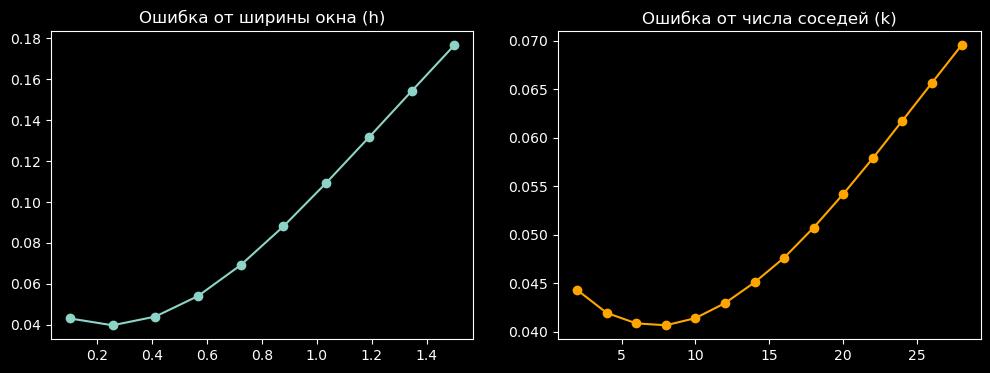

In [3]:
h_grid = np.linspace(0.1, 1.5, 10)
k_grid = range(2, 30, 2)

loo_h = [leave_one_out_regression(NadarayaWatson, {'h': h_val, 'kernel': 'gaussian'}, x_train, y) for h_val in h_grid]
loo_k = [leave_one_out_regression(NadarayaWatson, {'k': k_val, 'kernel': 'gaussian'}, x_train, y) for k_val in k_grid]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_grid, loo_h, marker='o')
plt.title("Ошибка от ширины окна (h)")
plt.subplot(1, 2, 2)
plt.plot(k_grid, loo_k, marker='o', color='orange')
plt.title("Ошибка от числа соседей (k)")
plt.show()

best_h = h_grid[np.argmin(loo_h)]
best_k = k_grid[np.argmin(loo_k)]

## 4. Визуализация прогноза

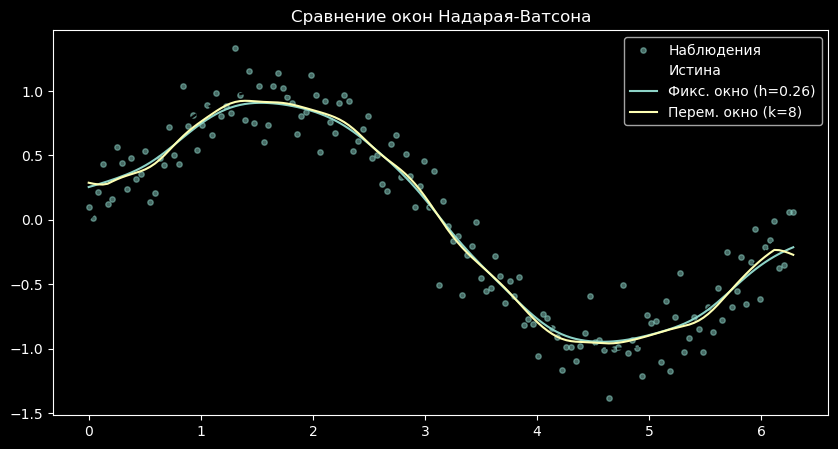

In [4]:
nw_fixed = NadarayaWatson(h=best_h).fit(x_train, y)
nw_var = NadarayaWatson(k=best_k).fit(x_train, y)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=15, alpha=0.5, label="Наблюдения")
plt.plot(x, y_true, 'k--', label="Истина")
plt.plot(x, nw_fixed.predict(x_train), label=f"Фикс. окно (h={best_h:.2f})")
plt.plot(x, nw_var.predict(x_train), label=f"Перем. окно (k={best_k})")
plt.legend()
plt.title("Сравнение окон Надарая-Ватсона")
plt.show()

## 5. LOWESS и устойчивость к выбросам

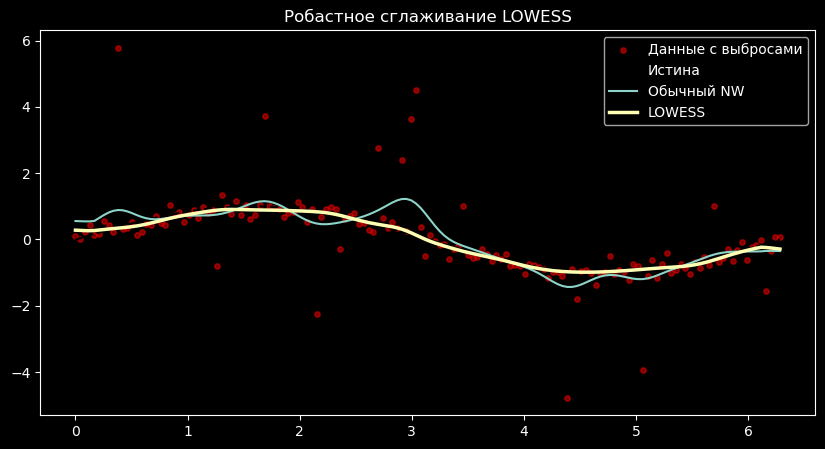

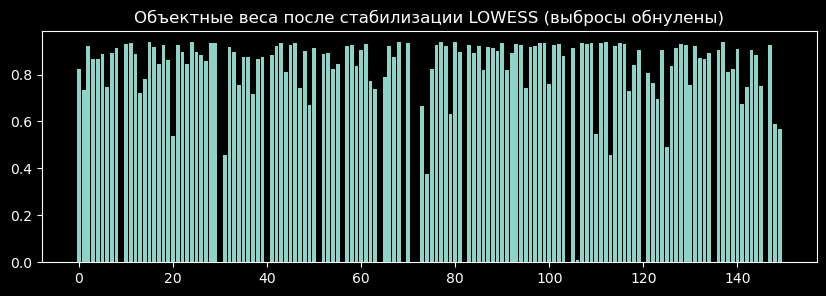

In [5]:
lowess = LOWESS(k=best_k, n_iter=5).fit(x_train, y_outliers)
nw_standard = NadarayaWatson(k=best_k).fit(x_train, y_outliers)

plt.figure(figsize=(10, 5))
plt.scatter(x, y_outliers, s=15, c='red', alpha=0.5, label="Данные с выбросами")
plt.plot(x, y_true, 'k--', label="Истина")
plt.plot(x, nw_standard.predict(x_train), label="Обычный NW")
plt.plot(x, lowess.predict(x_train), label="LOWESS", linewidth=2.5)
plt.legend()
plt.title("Робастное сглаживание LOWESS")
plt.show()

plt.figure(figsize=(10, 3))
plt.bar(range(len(lowess.robust_weights)), lowess.robust_weights)
plt.title("Объектные веса после стабилизации LOWESS (выбросы обнулены)")
plt.show()

## 6. Реальные данные

In [6]:
# Загрузка и подготовка первого реального датасета: Diabetes
diabetes = load_diabetes()
X_db, y_db = diabetes.data, diabetes.target
X_db_scaled = StandardScaler().fit_transform(X_db)
X_tr_db, X_te_db, y_tr_db, y_te_db = train_test_split(X_db_scaled, y_db, test_size=0.2, random_state=42)

model_db = NadarayaWatson(k=10, kernel='epanechnikov').fit(X_tr_db, y_tr_db)
preds_db = model_db.predict(X_te_db)

# Загрузка и подготовка второго реального датасета: California Housing
housing = fetch_california_housing()
X_hs, y_hs = housing.data, housing.target
X_hs_scaled = StandardScaler().fit_transform(X_hs)
X_tr_hs, X_te_hs, y_tr_hs, y_te_hs = train_test_split(X_hs_scaled, y_hs, test_size=0.2, random_state=42)

model_hs = NadarayaWatson(k=15, kernel='epanechnikov').fit(X_tr_hs, y_tr_hs)
preds_hs = model_hs.predict(X_te_hs)

# Сводная таблица результатов
metrics_df = pd.DataFrame({
    "Метрика": ["MAE", "RMSE", "R^2"],
    "Diabetes": [mae(y_te_db, preds_db), rmse(y_te_db, preds_db), r2_score(y_te_db, preds_db)],
    "California Housing (subset)": [mae(y_te_hs, preds_hs), rmse(y_te_hs, preds_hs), r2_score(y_te_hs, preds_hs)]
})

display(HTML("<h3>Метрики на реальных датасетах (Nadaraya-Watson)</h3>"))
display(metrics_df.style.format({
    "Diabetes": "{:.4f}",
    "California Housing (subset)": "{:.4f}"
}).hide(axis="index"))

Метрика,Diabetes,California Housing (subset)
MAE,41.8141,0.4304
RMSE,54.0419,0.6378
R^2,0.4488,0.6895
